# Stability Pairwise ARI

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
import sklearn.metrics
from tqdm import tqdm
import numpy as np
import pickle
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
import os
import corc.our_datasets
import corc.utils
import corc.our_algorithms

path = cache_path = '../../cache/'

In [4]:
def setup_plot_style():
    """Define common style elements for plots."""
    return {
        "colors": {
            "mnist": "#e41a1c",  # red
            "densired_circles_": "#87CEEB",  # light blue (earlier: cyan)
            "densired_studt_": "#377eb8",  # blue
            # "blobs1_": "#984ea3",  # purple
            # "blobs2_": "#4daf4a",  # green
        },
        "fontsize": {"labels": 6, "ticks": 6, "legend": 6},
    }


def create_errorbar_plot(ax, data_dict, dimensions, colors):
    """Create an errorbar plot for the given data."""
    for index, (dataset_name, subdict) in enumerate(data_dict.items()):
        for i, dim in enumerate(dimensions):
            try:
                vals = subdict[dim]
                mean_val = np.mean(vals)
                std_val = np.std(vals)
                label = dataset_name[:-1] if dataset_name.endswith("_") else dataset_name
                translated_label = corc.our_datasets.dataset_displaynames.get(
                    label, label
                )
                ax.errorbar(
                    i + index * 0.15 - len(dimensions) * 0.15 / 2,
                    mean_val,
                    yerr=std_val,
                    fmt="o",
                    color=colors[dataset_name],
                    label=label if i == 0 else "",
                    markersize=3,
                )
            except:
                pass


def style_axis(ax, key2_labels, fontsize, ylabel=None, xlabel=None):
    """Apply consistent styling to an axis."""
    ax.set_ylim(0, 1)
    ax.set_xticks(range(len(key2_labels)))
    ax.set_xticklabels(key2_labels)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=fontsize["labels"], labelpad=2)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=fontsize["labels"])
    ax.tick_params(labelsize=fontsize["ticks"])
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def plot_single_with_legend(pairwise_aris):
    style = setup_plot_style()
    labels = list(next(iter(pairwise_aris.values())).keys())
    figsize = (2, 1.8)
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(1, 2, height_ratios=[1], width_ratios=[1, 0.3])
    ax = fig.add_subplot(gs[0, 0])
    create_errorbar_plot(ax, pairwise_aris, labels, style["colors"])
    style_axis(
        ax, labels, style["fontsize"], ylabel="Pairwise ARI", xlabel="Dataset Dimension"
    )

    # Add legend to the right of the plots
    handles, labels = ax.get_legend_handles_labels()
    legend = fig.legend(
        handles,
        (corc.our_datasets.dataset_displaynames[label] for label in labels),
        frameon=False,
        fontsize=style["fontsize"]["legend"],
        loc="center right",
        bbox_to_anchor=(1, 0.5),
        handletextpad=0.01,
        scatterpoints=1,
    )
    return fig


def plot_single(pairwise_aris):
    style = setup_plot_style()
    labels = list(next(iter(pairwise_aris.values())).keys())

    figsize = (1.4, 1.8)
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(1, 1, 1)
    create_errorbar_plot(ax, pairwise_aris, labels, style["colors"])
    style_axis(
        ax, labels, style["fontsize"], ylabel="Pairwise ARI", xlabel="Dataset Dimension"
    )
    return fig


# fig = plot_single_with_legend(tmm_overclustering)
# fig2 = plot_single(tmm_overclustering)

## Stability

In [ ]:
all_aris = dict()

In [85]:
algo = "UniForCE"
# algo = "TMM-NEB"
dataset_name = "densired_studt_8"
dataset_name = "densired_circles_8"
X,y,tsne, params = corc.utils.load_dataset(dataset_name, index=0, cache_path=cache_path, return_params=True)
algos = corc.utils.load_algorithms(dataset_name, algo, cache_path=cache_path, index=0)

In [91]:
dataset_names = corc.our_datasets.COMPLEX_DATASETS

for dataset_name in dataset_names:
    print(dataset_name)
    num_datasets = 10 if dataset_name.lower().startswith("densired") else 1
    for index in range(num_datasets):
        X, y, tsne = corc.utils.load_dataset(dataset_name, cache_path=cache_path, index=index)
        if dataset_name not in all_aris:
            all_aris[dataset_name] = dict()
        if index not in all_aris[dataset_name]:
            all_aris[dataset_name][index] = dict()
        for algo in ["TMM-NEB", "GMM-NEB", "UniForCE"]:
            if not algo in all_aris[dataset_name][index].keys():
                algos = corc.utils.load_algorithms(dataset_name, algorithm=algo, cache_path=cache_path, index=index)
                _, predictions, _ = corc.utils.get_predictions(algorithms=algos, X=X, num_classes=len(np.unique(y)))
                pairwise_aris = list()
                for y_pred1,y_pred2 in combinations(predictions,2):
                    pairwise_aris.append(adjusted_rand_score(y_pred1,y_pred2))

                all_aris[dataset_name][index][algo] = pairwise_aris

with open(os.path.join(cache_path,"metrics", "stability_seeds.pkl"), "wb") as f:
    pickle.dump(all_aris, f)

densired_circles_8
6 clusters is not achievable.
Working with 5 clusters instead.
densired_circles_16
densired_circles_32
densired_circles_64
densired_studt_8
densired_studt_16
6 clusters is not achievable.
Working with 1 clusters instead.
densired_studt_32
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 1 clusters instead.
6 clusters is not achievable.
Working with 5 clus

In [19]:
metrics_file = os.path.join(cache_path, "metrics", "stability_seeds.pkl")
with open(metrics_file, "rb") as f:
    all_aris = pickle.load(f)

In [ ]:
# reorder datastructure for seed stability plotting
pairwise_aris_summary = dict()
for algorithm in ["TMM-NEB", "GMM-NEB", "UniForCE"]:
    pairwise_aris_summary[algorithm] = dict()
    for dataset_name in ["densired_circles_", "densired_studt_", "mnist"]:
        pairwise_aris_summary[algorithm][dataset_name] = dict()
        for dimension in [8,16,32,64]:
            pairwise_aris_summary[algorithm][dataset_name][dimension] = list()
            max_index = 10 if dataset_name.lower().startswith("densired") else 1
            for index in range(max_index):
                pairwise_aris_summary[algorithm][dataset_name][dimension].append(all_aris[f"{dataset_name}{dimension}"][index][algorithm])

In [ ]:
# overclustering data collection
overclustering_ari_summary = dict()
algorithm = "TMM-NEB"
for dataset_name in ["densired_circles_", "densired_studt_", "mnist"]:
    overclustering_ari_summary[dataset_name] = dict()
    for dimension in [8,16,32,64]:
        overclustering_ari_summary[dataset_name][dimension] = list()
        max_index = 10 if dataset_name.lower().startswith("densired") else 1
        for index in range(max_index):

            X,y,tsne = corc.utils.load_dataset(f"{dataset_name}{dimension}", index=index, cache_path=cache_path)
            with open(f"{cache_path}/stability/overclustering_{dataset_name}{dimension}-{index}.pkl", "rb") as f:
                algos = pickle.load(f)
            _, predictions, _ = corc.utils.get_predictions(algos, X, len(np.unique(y)))
            for y_pred1,y_pred2 in combinations(predictions, 2):
                overclustering_ari_summary[dataset_name][dimension].append(
                    adjusted_rand_score(y_pred1,y_pred2)
                )

[array([4, 4, 4, ..., 5, 2, 0]), array([0, 0, 0, ..., 2, 5, 3]), array([3, 3, 3, ..., 4, 0, 1]), array([3, 3, 3, ..., 1, 5, 2]), array([4, 4, 4, ..., 5, 3, 0]), array([1, 1, 1, ..., 0, 5, 4]), array([3, 3, 3, ..., 2, 5, 1]), array([3, 3, 3, ..., 5, 4, 1]), array([3, 3, 3, ..., 1, 5, 4]), array([2, 2, 2, ..., 0, 5, 4]), array([1, 1, 1, ..., 5, 4, 0]), array([0, 0, 0, ..., 1, 5, 3]), array([3, 3, 3, ..., 2, 5, 1]), array([4, 4, 4, ..., 5, 1, 2]), array([4, 4, 3, ..., 1, 2, 0])]
[array([3, 3, 3, ..., 4, 2, 3]), array([0, 0, 0, ..., 3, 0, 0]), array([0, 0, 0, ..., 5, 3, 0]), array([2, 2, 2, ..., 0, 3, 2]), array([2, 2, 2, ..., 0, 2, 2]), array([5, 5, 5, ..., 0, 0, 5]), array([1, 1, 1, ..., 1, 1, 1]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0])]
[array([3, 3, 3, ..., 4, 1, 2]), array

In [ ]:
def tmm_overclustering_ari(gmm=""):
    ds_starts = ['mnist', 'densired', 'densired_soft_']
    ds_dims = [8, 16, 32, 64]
    ari_per_dataset_overclustering = {}
    for ds_name in tqdm(ds_starts):
        ari_per_dataset_overclustering[ds_name] = {}
        for dim in ds_dims:
            # if ds_name == 'blobs1_' and dim == 64:
            #     continue
            ari_per_dataset_overclustering[ds_name][dim] = []
            
            filepath = f'{path}stability/overclustering_{ds_name}{dim}{gmm}.pkl'
            if os.path.exists(filepath):
                with open(filepath, 'rb') as f:
                    tmm_models = pickle.load(f)
            else:
                continue
            
            # skip first two models as they do not use proper "joining" of clusters
            tmm_models = tmm_models[2:10]
                
            X, y, tsne = corc.utils.load_dataset(f'{ds_name}{dim}',cache_path=cache_path)
            n_classes = len(np.unique(y))
            predictions = {s: s.predict_with_target(X, n_classes) for s in tmm_models}

            # pairwise ari
            for model1, model2 in combinations(tmm_models, 2):
                ari_per_dataset_overclustering[ds_name][dim].append(
                    adjusted_rand_score(predictions[model1], predictions[model2])
                )
    return ari_per_dataset_overclustering

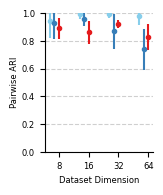

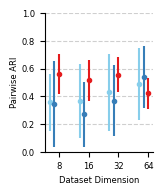

In [94]:
fig = plot_single(pairwise_aris_summary["TMM-NEB"])
fig.savefig("../../figures/stability/tmm.pdf", bbox_inches='tight', pad_inches=0)

# fig = plot_single(smmp_seed)
# fig.savefig("../../figures/stability/smmp.pdf", bbox_inches='tight', pad_inches=0)

fig = plot_single(pairwise_aris_summary["UniForCE"])
fig.savefig("../../figures/stability/uniforce.pdf", bbox_inches='tight', pad_inches=0)

# fig = plot_single_with_legend(tmm_overclustering)
# fig.savefig("../../figures/stability/tmm_overclustering.pdf", bbox_inches='tight', pad_inches=0)


In [15]:
keys = ['mnist', 'densired', 'densired_soft_']
main_ari_per_dataset_seeds = {key: ari_per_dataset_seeds[key] for key in keys }
# main_ari_per_dataset_overclustering = dict()
main_ari_per_dataset_overclustering = {key: ari_per_dataset_overclustering[key] for key in keys}

/user/ritzert/u14643/micromamba/envs/tneb/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/user/ritzert/u14643/micromamba/envs/tneb/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/user/ritzert/u14643/micromamba/envs/tneb/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/user/ritzert/u14643/micromamba/envs/tneb/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/user/ritzert/u14643/micromamba/envs/tneb/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


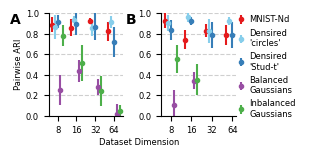

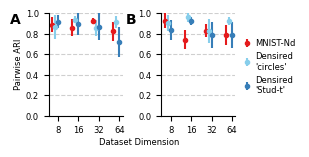

In [ ]:
# fig, axes = plot_comparison(ari_per_dataset_seeds, ari_per_dataset_overclustering)
# plt.savefig(f"../../figures/stability_errorbars{gmm}_full.pdf",
#             bbox_inches='tight', pad_inches=0)

fig, axes = plot_comparison(main_ari_per_dataset_seeds, main_ari_per_dataset_overclustering)
plt.savefig(f"../../figures/stability_errorbars{gmm}2.pdf",
            bbox_inches='tight', pad_inches=0)